## Notebook 4: Impact Functions

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
SUMMARY OF NOTEBOOK
</blockquote>

In [1]:
import os
os.environ["CITY"] = "rome"   # pick the city here

In [2]:
# Generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: rome  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim


In [3]:
cfg  = C.get("cfg")     # dict loaded from YAML

**from Notebook 3**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from climada.hazard import Hazard
from climada.entity.exposures import Exposures
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet
from climada.engine import ImpactCalc

plt.rcParams.update({"figure.dpi": 130})

# loading hazard and exposure produced in Notebook 3
haz_path = INT / f"hazard_T2M_daily_{SLUG}.h5"
exp_path = INT / f"exposure_people_{SLUG}.h5"

H   = Hazard.from_hdf5(haz_path)
exp = Exposures.from_hdf5(exp_path)

# repairing daily metadata 
def reattach_daily_dates(INT, SLUG, H):
    csv = INT / f"hazard_T2M_daily_events_{SLUG}.csv"
    df = pd.read_csv(csv)
    # keeping original row order
    df = df.sort_values("row").reset_index(drop=True)

    n = H.intensity.shape[0]
    assert len(df) == n, f"Events CSV rows ({len(df)}) != hazard rows ({n})."

    H.event_id = df["event_id"].to_numpy(int)
    H.date = pd.to_datetime(df["date"]).to_numpy("datetime64[ns]")
    H.event_name = np.array([f"T2M_{d.date()}" for d in pd.to_datetime(df["date"])], dtype=object)
    if not hasattr(H, "frequency") or len(getattr(H, "frequency", [])) != n:
        H.frequency = np.ones(n, dtype=float)
    return H

H = reattach_daily_dates(INT, SLUG, H)

if not hasattr(H, "date") or len(getattr(H, "date", [])) != H.intensity.shape[0]:
    raise RuntimeError("Daily dates not present in hazard. Re-run NB3 saving steps.")

# Event-year index from daily dates
dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
year_idx = dates.dt.year.to_numpy(int)  # length = n_days

In [5]:
citymean_daily = np.asarray(H.intensity.mean(axis=1)).ravel()
pd.DataFrame({"date": dates, "citymean_degC": citymean_daily}).head(10)

,date,citymean_degC
0,2030-01-01,7.702040
1,2030-01-02,7.985860
2,2030-01-03,8.538031
3,2030-01-04,8.035543
4,2030-01-05,8.067746
5,2030-01-06,7.802955
6,2030-01-07,8.059461
7,2030-01-08,8.708427
8,2030-01-09,8.498875
9,2030-01-10,8.705299


Age-group population totals from exp (because later we do per-100k by group)

In [6]:
age_pop = (
    exp.gdf.groupby("age_group")["value"]
    .sum()
    .astype(float)
    .sort_index()
)
print("Population by age group on WBGT grid:")
print(age_pop)
print("Total population on WBGT grid:", float(age_pop.sum()))

Population by age group on WBGT grid:
age_group
15-64    1.580341e+06
65+      6.906694e+05
<15      2.771438e+05
Name: value, dtype: float64
Total population on WBGT grid: 2548153.9153858856


> **Impact Funtions in Climada:**
> - What changes compared to before?
> - Before: one event per year and intensity = “hot days/year”.
> - Now: one event per day, intensity is daily mean T (°C).

In [7]:
SLUG = cfg.get("slug", SLUG)
cfg_if = cfg.get("impact_functions", {}) # loading IF para from YAML

In [19]:
AGE_PARAMS = cfg_if.get("age_params", {
    # tau (degC daily mean) is the "turn-on" temp (as before) : where risk kicks in, gamma controls convexity (curvature)
    # ie how fast mortality explodes when temperature raises 
    # ids must match exp.gdf['impf_T2M']
    "<15":   {"tau_days": 26.0, "gamma": 2.0, "impf_id": 1, "name": "Children"},
    "15-64": {"tau_days": 25.0, "gamma": 2.3, "impf_id": 2, "name": "Adults"},
    "65+":   {"tau_days": 18.0, "gamma": 2.6, "impf_id": 3, "name": "Elderly"},
})
BASELINE_PER100K = cfg_if.get("baseline_per100k", {"<15": 1.7, "15-64": 70.0, "65+": 3129.0})
TOTAL_TARGET_PER100K = float(cfg_if.get("total_target_per100k", 91.0))  # target overall heat deaths /100k
REPORT_YEAR = int(cfg_if.get("report_year", dates.dt.year.max()))       # anchor year for scaling (here, 2050)
PRE_SCALE_MDD = float(cfg_if.get("pre_scale_mdd", 1e-6))                # per-day tiny scale before anchoring

In [20]:
# build age-specific heat-only IFs in °C 
def make_power_if_C(H, tau_C, gamma, impf_id, name, pre_scale=1e-6):
    # intensity grid in °C covering observed range
    Imax = float(H.intensity.max()) * 1.05
    x = np.linspace(0.0, max(35.0, Imax), 256)  
    # heat-only: zero below τ, convex above
    y = np.maximum(0.0, x - float(tau_C)) ** float(gamma)
    if y.max() > 0:
        y = y / y.max() * pre_scale  # per-person-per-day baseline height 
    impf = ImpactFunc(
        haz_type="T2M", id=int(impf_id),
        intensity=x.astype(float),
        mdd=y.astype(float),               # daily MDD
        paa=np.ones_like(x, dtype=float),
        name=name
    )
    impf.check()
    return impf

age_ifs = {
    grp: make_power_if_C(H, p["tau_days"], p["gamma"], p["impf_id"], p.get("name", grp), PRE_SCALE_MDD)
    for grp, p in AGE_PARAMS.items()
}

In [21]:
# weight IFs by baseline all-cause mortality (older groups have higher absolute rates) 
ref_age = "15-64"
ref = float(BASELINE_PER100K[ref_age])
for a, f in age_ifs.items():
    f.mdd *= float(BASELINE_PER100K[a]) / ref

In [22]:
# run helper: impacts + rates per 100k, but now on daily events 
def subset_exposure(exp_obj, age_label):
    m = (exp_obj.gdf["age_group"] == age_label)
    if not m.any(): return None
    sub = Exposures(); sub.set_gdf(exp_obj.gdf.loc[m].copy())
    sub.value_unit, sub.ref_year = exp_obj.value_unit, getattr(exp_obj, "ref_year", None)
    return sub

def run_one(exp_obj, H, fset):
    ifs = ImpactFuncSet(list(fset.values()))
    imp = ImpactCalc(exp_obj, ifs, H).impact()
    totals = np.ravel(imp.at_event)                 # deaths per day (event)
    pop = float(exp_obj.gdf["value"].sum())
    per100k = totals / pop * 1e5 if pop > 0 else np.zeros_like(totals)
    return totals, per100k

def run_by_age(exp_obj, H, age_ifs):
    out = {}
    for a, f in age_ifs.items():
        sub = subset_exposure(exp_obj, a)
        if (sub is None) or (float(sub.gdf["value"].sum()) == 0):
            out[a] = {"totals": np.zeros(H.intensity.shape[0]), "per100k": np.zeros(H.intensity.shape[0])}
        else:
            t, r = run_one(sub, H, {a: f})
            out[a] = {"totals": t, "per100k": r}
    return out

In [23]:
# preliminary run to compute a scale so that REPORT_YEAR overall hits target per-100k 
# overall = population-weighted across ages
pre_by_age = run_by_age(exp, H, age_ifs)
age_pop = exp.gdf.groupby("age_group")["value"].sum().astype(float)
weights = {a: (age_pop[a] / age_pop.sum()) for a in age_pop.index}

per100k_overall_daily = sum(pre_by_age[a]["per100k"] * weights.get(a, 0.0) for a in age_ifs.keys())
# aggregate daily to yearly for the report year
df_overall = pd.DataFrame({"year": year_idx, "rate": per100k_overall_daily})
curr_report = float(df_overall.loc[df_overall["year"] == REPORT_YEAR, "rate"].sum())
target_report = float(TOTAL_TARGET_PER100K)

scale = (target_report / curr_report) if curr_report > 0 else 1.0
for f in age_ifs.values():
    f.mdd *= scale
print(f"Applied global scaling x{scale:.3f} to match {REPORT_YEAR} overall = {target_report:.1f} per 100k.")

Applied global scaling x0.004 to match 2050 overall = 91.0 per 100k.


In [24]:
# final run with scaled IFs 
by_age = run_by_age(exp, H, age_ifs)

# daily to yearly tables
def daily_to_yearly(arr_daily):
    return pd.Series(arr_daily).groupby(year_idx).sum()

yr_rates = pd.DataFrame({a: daily_to_yearly(by_age[a]["per100k"]) for a in age_ifs.keys()})
yr_rates["overall"] = sum(yr_rates[a] * weights.get(a, 0.0) for a in age_ifs.keys())

yr_deaths = pd.DataFrame({a: daily_to_yearly(by_age[a]["totals"]) for a in age_ifs.keys()})
yr_deaths["overall"] = yr_deaths.sum(axis=1)

print("Per-100k heat mortality by year (rows) and age (cols):")
display(yr_rates.round(3))

print("Heat deaths (absolute) by year and age:")
display(yr_deaths.round(1))

Per-100k heat mortality by year (rows) and age (cols):


,<15,15-64,65+,overall
2030,0.028,1.466,324.673,88.914
2040,0.023,1.257,311.293,85.157
2050,0.030,1.541,332.197,91.000


Heat deaths (absolute) by year and age:


,<15,15-64,65+,overall
2030,0.1,23.2,2242.4,2265.7
2040,0.1,19.9,2150.0,2169.9
2050,0.1,24.4,2294.4,2318.8


note: no worries about the fact that the overall is smaller than the sum in table 1: overall is a pop-weighted average of per 100k rates (not a sum). Each age column: heat deaths per 100k within that age group.

In [25]:
# per-100k by year (daily summed within year)
age_keys = ["<15","15-64","65+"]
for age in age_keys:
    d = {int(y): float(v) for y, v in yr_rates[age].items()}
    print(f"{age:>5} per-100k by event:", d)

# Overall as population-weighted combo of the age rates (should match yr_rates["overall"])
overall_pw = sum(yr_rates[a] * weights.get(a, 0.0) for a in age_keys)
print("Population-weighted(by age) == overall rates_all?",
      np.allclose(overall_pw.values, yr_rates["overall"].values))

  <15 per-100k by event: {2030: 0.028472630697419583, 2040: 0.023447463622413744, 2050: 0.030333621853315673}
15-64 per-100k by event: {2030: 1.4662203253937087, 2040: 1.2566808588003529, 2050: 1.5408464661825585}
  65+ per-100k by event: {2030: 324.67275527419287, 2040: 311.29283208595524, 2050: 332.19733215805144}
Population-weighted(by age) == overall rates_all? True


In [26]:
# absolute deaths
for age in age_keys:
    d = {int(y): float(v) for y, v in yr_deaths[age].items()}
    print(f"{age:>5} deaths by event:", d)
d_all = {int(y): float(v) for y, v in yr_deaths["overall"].items()}
print("overall deaths by event:", d_all)

  <15 deaths by event: {2030: 0.07891012445866295, 2040: 0.06498318656773519, 2050: 0.08406774565948655}
15-64 deaths by event: {2030: 23.171276877760732, 2040: 19.859839358335268, 2050: 24.350624169971315}
  65+ deaths by event: {2030: 2242.4154199309523, 2040: 2150.004382702228, 2050: 2294.385371085525}
overall deaths by event: {2030: 2265.6656069331716, 2040: 2169.929205247131, 2050: 2318.820063001156}


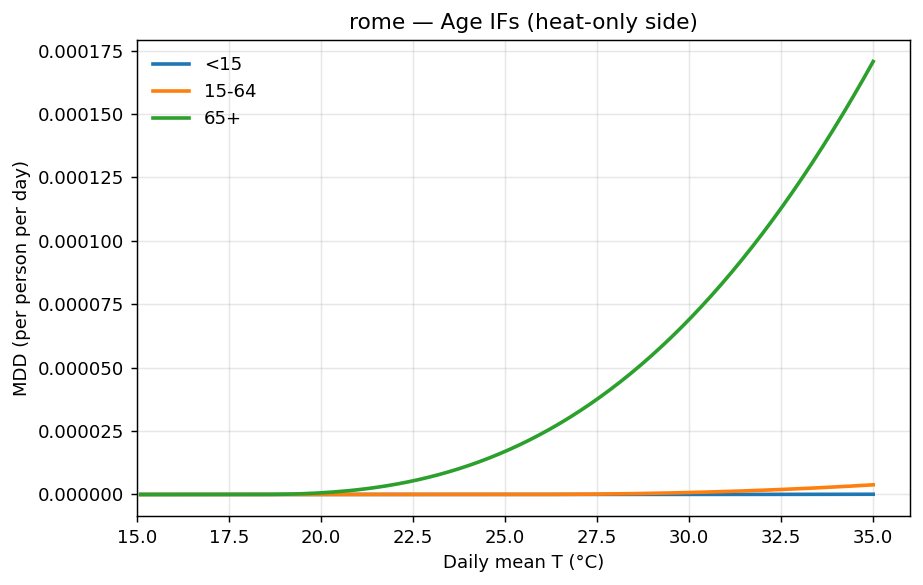

In [27]:
# sanity plot 
plt.figure(figsize=(7.2,4.6))
for a, f in age_ifs.items():
    m = f.intensity >= 15
    plt.plot(f.intensity[m], f.mdd[m], linewidth=2, label=a)
plt.xlim(15, 36)          
plt.xlabel("Daily mean T (°C)")
plt.ylabel("MDD (per person per day)")
plt.title(f"{CITY} — Age IFs (heat-only side)")
plt.grid(alpha=0.3); plt.legend(frameon=False); plt.tight_layout(); plt.show()

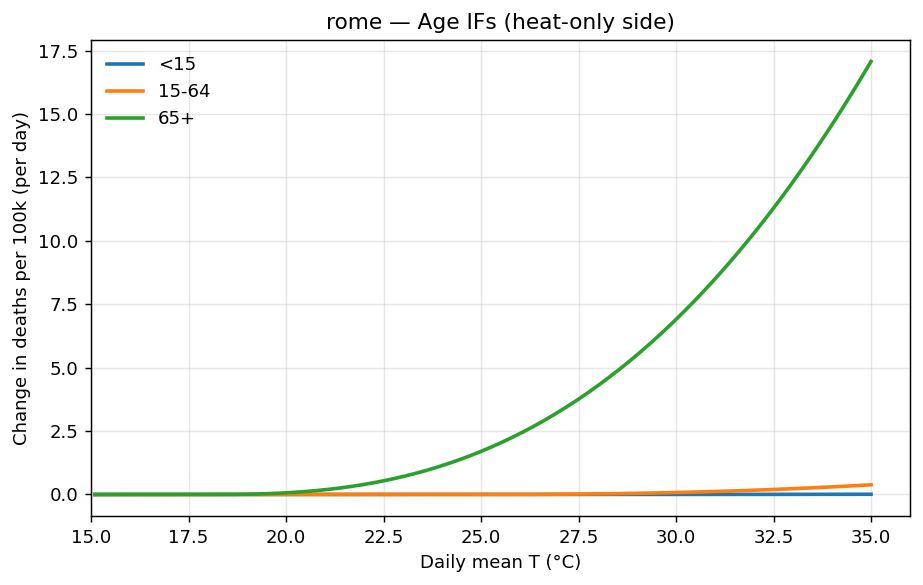

In [28]:
# IFs in per-100k per day, heat-only, 15–35°C
plt.figure(figsize=(7.2,4.6))
for a, f in age_ifs.items():
    T = f.intensity
    y = 1e5 * f.mdd          # converting from per person per day -> per 100k per day
    m = T >= 15              # hide cold side
    plt.plot(T[m], y[m], linewidth=2, label=a)

plt.xlim(15, 36)
plt.xlabel("Daily mean T (°C)")
plt.ylabel("Change in deaths per 100k (per day)")
plt.title(f"{CITY} — Age IFs (heat-only side)")
plt.grid(alpha=0.3); plt.legend(frameon=False); plt.tight_layout(); plt.show()

In [29]:
import json
from pathlib import Path

freeze = {k: {"id": int(v.id), "name": getattr(v,"name",k),
              "intensity": np.asarray(v.intensity,float).tolist(),
              "mdd": np.asarray(v.mdd,float).tolist()} for k,v in age_ifs.items()}
with open(INT / f"if_curves_frozen_{SLUG}.json", "w") as fh:
    json.dump(freeze, fh)
print("Wrote", INT / f"if_curves_frozen_{SLUG}.json")

Wrote /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/if_curves_frozen_rome.json
